# Problema 2 - Redes Neuronales para Intersección de Curvas (30 Puntos)

Desarrollar redes neuronales con aprendizaje automatizado, graficando en una imagen todas las curvas. Encontrar los puntos de intersección entre las curvas.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1773432248.881196    9857 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773432248.881684    9857 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773432249.034189    9857 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773432251.377116    9857 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773432251.377493    9857 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
pares = [
    {'id': 'a', 'f': lambda x: x**2 - 2*x + 1, 'g': lambda x: -x**2 + 5*x - 2,
     'f_str': r'$y = x^2 - 2x + 1$', 'g_str': r'$y = -x^2 + 5x - 2$'},
    {'id': 'b', 'f': lambda x: x**2 + 1, 'g': lambda x: x + 1,
     'f_str': r'$y = x^2 + 1$', 'g_str': r'$y = x + 1$'},
    {'id': 'c', 'f': lambda x: x**2 - 3*x + 1, 'g': lambda x: x + 1,
     'f_str': r'$y = x^2 - 3x + 1$', 'g_str': r'$y = x + 1$'},
    {'id': 'd', 'f': lambda x: 2 - x**2, 'g': lambda x: x**2,
     'f_str': r'$y = 2 - x^2$', 'g_str': r'$y = x^2$'},
    {'id': 'e', 'f': lambda x: 2*x - x**2, 'g': lambda x: x - 2,
     'f_str': r'$y = 2x - x^2$', 'g_str': r'$y = x - 2$'},
    {'id': 'f', 'f': lambda x: x**2 - 4, 'g': lambda x: 3*x - x**2 + 1,
     'f_str': r'$y = x^2 - 4$', 'g_str': r'$y = 3x - x^2 + 1$'},
]

In [3]:
def crear_red_curva():
    modelo = keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(15, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(15, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(1, activation='linear')
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='mse', metrics=['mae'])
    return modelo

def encontrar_intersecciones(func_f, func_g, x_min=-5, x_max=5):
    intersecciones = []
    for x0 in np.linspace(x_min, x_max, 30):
        try:
            x_sol = fsolve(lambda x: func_f(x) - func_g(x), x0, full_output=True)
            if x_sol[2] == 1:
                xs = float(x_sol[0][0])
                if x_min - 0.5 <= xs <= x_max + 0.5:
                    es_nuevo = all(abs(xs - xp) > 0.01 for xp, _ in intersecciones)
                    if es_nuevo:
                        intersecciones.append((xs, float(func_f(xs))))
        except:
            pass
    return sorted(intersecciones, key=lambda p: p[0])

In [4]:
x_min, x_max = -5, 5
n_puntos = 500
X_train_base = np.linspace(x_min, x_max, n_puntos)
X_norm = (X_train_base - x_min) / (x_max - x_min)

resultados = []

for par in pares:
    Y_f = par['f'](X_train_base)
    Y_g = par['g'](X_train_base)
    
    Y_f_mean, Y_f_std = np.mean(Y_f), np.std(Y_f)
    Y_g_mean, Y_g_std = np.mean(Y_g), np.std(Y_g)
    Y_f_norm = (Y_f - Y_f_mean) / Y_f_std
    Y_g_norm = (Y_g - Y_g_mean) / Y_g_std
    
    indices = np.random.permutation(n_puntos)
    n_train = int(0.8 * n_puntos)
    
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
    
    modelo_f = crear_red_curva()
    modelo_f.fit(X_norm[indices[:n_train]].reshape(-1, 1), Y_f_norm[indices[:n_train]].reshape(-1, 1),
                 validation_data=(X_norm[indices[n_train:]].reshape(-1, 1), Y_f_norm[indices[n_train:]].reshape(-1, 1)),
                 epochs=1500, batch_size=32, verbose=0, callbacks=[early_stop])
    
    modelo_g = crear_red_curva()
    modelo_g.fit(X_norm[indices[:n_train]].reshape(-1, 1), Y_g_norm[indices[:n_train]].reshape(-1, 1),
                 validation_data=(X_norm[indices[n_train:]].reshape(-1, 1), Y_g_norm[indices[n_train:]].reshape(-1, 1)),
                 epochs=1500, batch_size=32, verbose=0, callbacks=[early_stop])
    
    resultados.append({
        'par': par, 'modelo_f': modelo_f, 'modelo_g': modelo_g,
        'Y_f_mean': Y_f_mean, 'Y_f_std': Y_f_std,
        'Y_g_mean': Y_g_mean, 'Y_g_std': Y_g_std
    })
    print(f"Par {par['id']} entrenado")

E0000 00:00:1773432252.440585    9857 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Par a entrenado


Par b entrenado


Par c entrenado


Par d entrenado


Par e entrenado


Par f entrenado


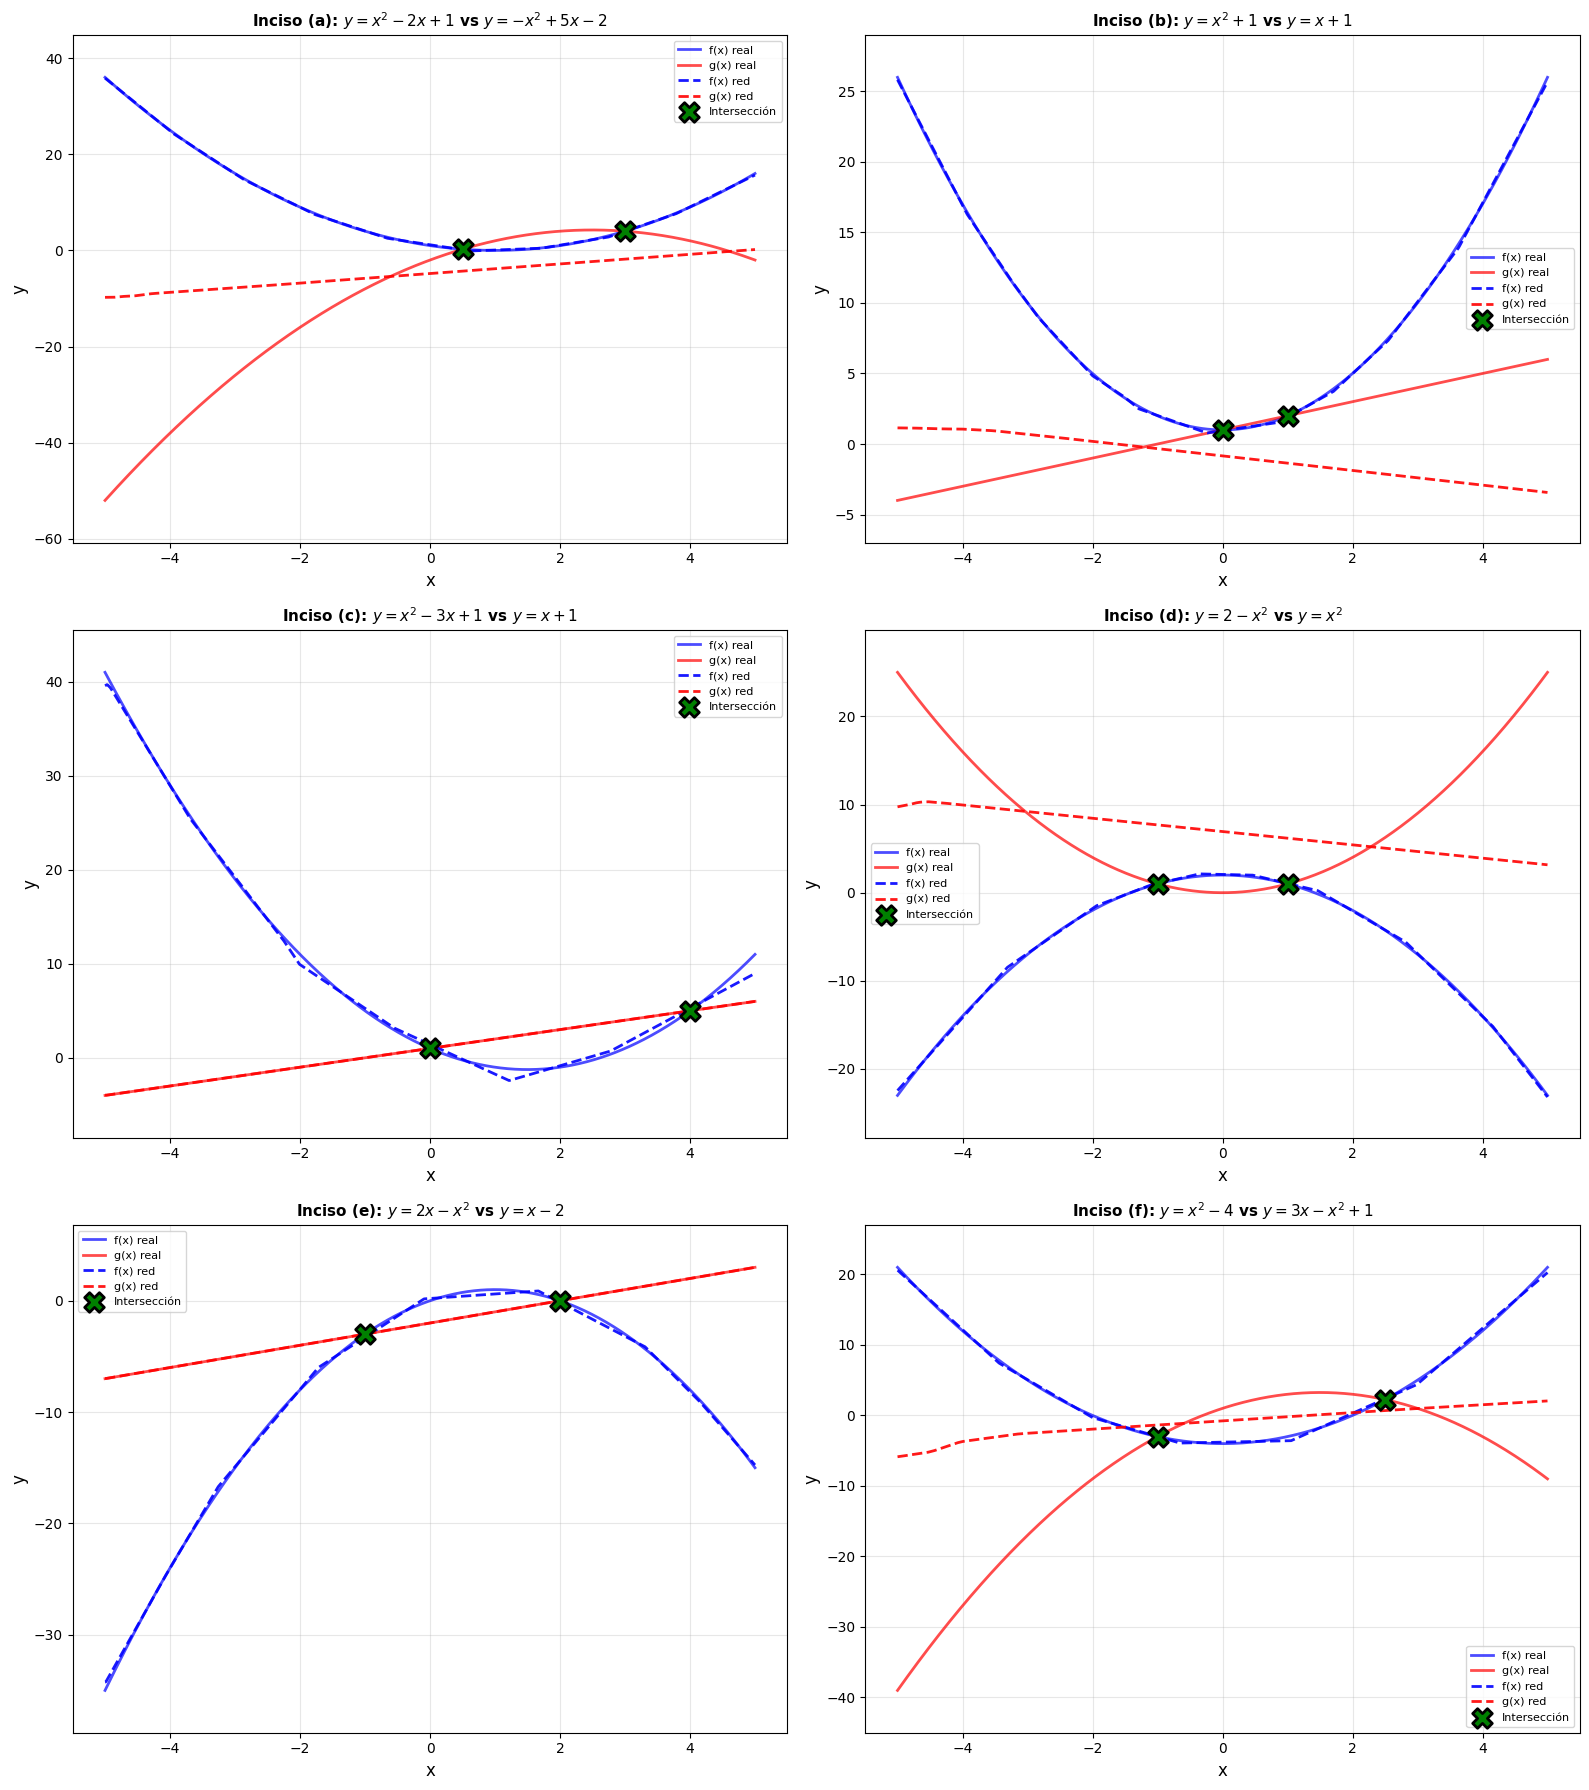

In [5]:
x_denso = np.linspace(x_min, x_max, 1000)
x_denso_norm = (x_denso - x_min) / (x_max - x_min)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for idx, res in enumerate(resultados):
    ax = axes[idx // 2][idx % 2]
    par = res['par']
    
    y_f_real = par['f'](x_denso)
    y_g_real = par['g'](x_denso)
    
    pred_f_norm = res['modelo_f'].predict(x_denso_norm.reshape(-1, 1), verbose=0)
    pred_f = pred_f_norm.flatten() * res['Y_f_std'] + res['Y_f_mean']
    pred_g_norm = res['modelo_g'].predict(x_denso_norm.reshape(-1, 1), verbose=0)
    pred_g = pred_g_norm.flatten() * res['Y_g_std'] + res['Y_g_mean']
    
    ax.plot(x_denso, y_f_real, 'b-', linewidth=2, alpha=0.7, label=f'f(x) real')
    ax.plot(x_denso, y_g_real, 'r-', linewidth=2, alpha=0.7, label=f'g(x) real')
    ax.plot(x_denso, pred_f, 'b--', linewidth=2, alpha=0.9, label=f'f(x) red')
    ax.plot(x_denso, pred_g, 'r--', linewidth=2, alpha=0.9, label=f'g(x) red')
    
    intersecciones = encontrar_intersecciones(par['f'], par['g'], x_min, x_max)
    if intersecciones:
        xi = [p[0] for p in intersecciones]
        yi = [p[1] for p in intersecciones]
        ax.scatter(xi, yi, color='green', s=200, marker='X', edgecolors='black', linewidth=2, zorder=5, label='Intersección')
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title(f'Inciso ({par["id"]}): {par["f_str"]} vs {par["g_str"]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    y_all = np.concatenate([y_f_real, y_g_real])
    y_range = np.max(y_all) - np.min(y_all)
    ax.set_ylim(np.min(y_all) - 0.1 * y_range, np.max(y_all) + 0.1 * y_range)

plt.tight_layout()
plt.savefig('problema_2_incisos.png', dpi=300, bbox_inches='tight')
plt.show()

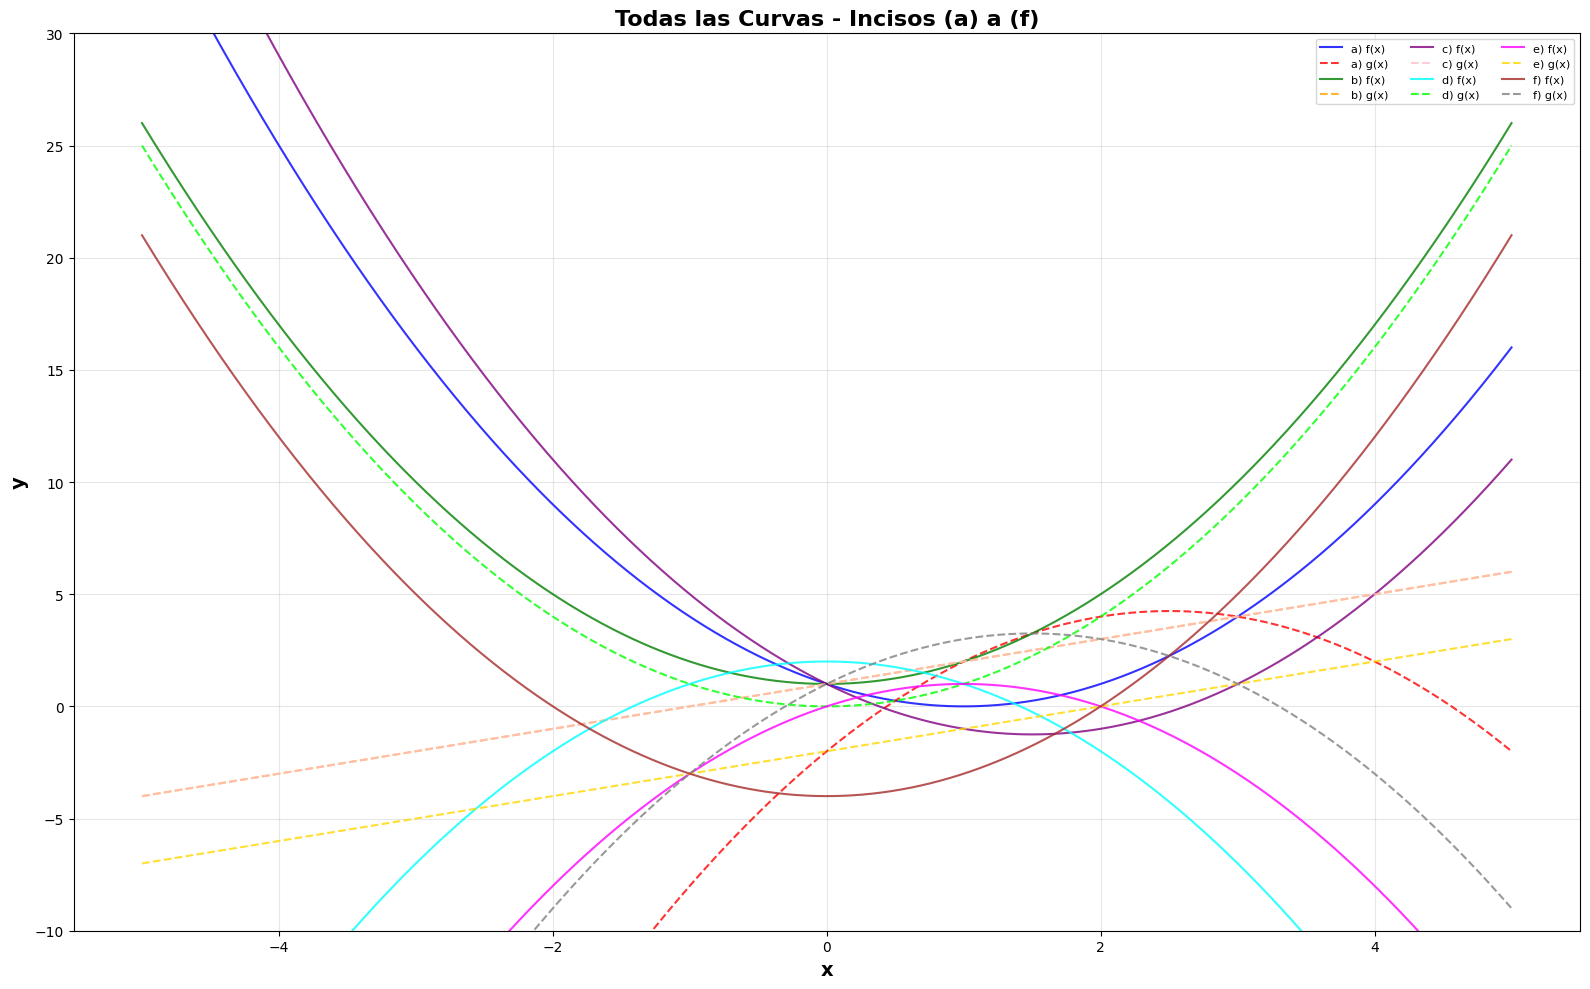

In [6]:
colores_f = ['blue', 'green', 'purple', 'cyan', 'magenta', 'brown']
colores_g = ['red', 'orange', 'pink', 'lime', 'gold', 'gray']

plt.figure(figsize=(16, 10))

for idx, res in enumerate(resultados):
    par = res['par']
    y_f_real = par['f'](x_denso)
    y_g_real = par['g'](x_denso)
    
    plt.plot(x_denso, y_f_real, color=colores_f[idx], linewidth=1.5, alpha=0.8, label=f'{par["id"]}) f(x)')
    plt.plot(x_denso, y_g_real, color=colores_g[idx], linewidth=1.5, linestyle='--', alpha=0.8, label=f'{par["id"]}) g(x)')

plt.xlabel('x', fontsize=14, fontweight='bold')
plt.ylabel('y', fontsize=14, fontweight='bold')
plt.title('Todas las Curvas - Incisos (a) a (f)', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=8, ncol=3)
plt.grid(True, alpha=0.3)
plt.ylim(-10, 30)
plt.tight_layout()
plt.savefig('problema_2_todas_curvas.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print(f"{'Inciso':<10} {'Intersección':<30} {'MSE f(x)':<15} {'MSE g(x)':<15}")
print('=' * 70)

mse_f_list = []
mse_g_list = []
par_labels = []

for res in resultados:
    par = res['par']
    
    intersecciones = encontrar_intersecciones(par['f'], par['g'], x_min, x_max)
    
    x_test = np.linspace(x_min, x_max, 200)
    x_test_norm = (x_test - x_min) / (x_max - x_min)
    
    pred_f = res['modelo_f'].predict(x_test_norm.reshape(-1, 1), verbose=0).flatten() * res['Y_f_std'] + res['Y_f_mean']
    pred_g = res['modelo_g'].predict(x_test_norm.reshape(-1, 1), verbose=0).flatten() * res['Y_g_std'] + res['Y_g_mean']
    
    mse_f = np.mean((par['f'](x_test) - pred_f) ** 2)
    mse_g = np.mean((par['g'](x_test) - pred_g) ** 2)
    mse_f_list.append(mse_f)
    mse_g_list.append(mse_g)
    par_labels.append(f"({par['id']})")
    
    int_str = ', '.join([f'({x:.4f}, {y:.4f})' for x, y in intersecciones])
    print(f"{par['id']:<10} {int_str:<30} {mse_f:<15.6f} {mse_g:<15.6f}")

Inciso     Intersección                   MSE f(x)        MSE g(x)       
a          (0.5000, 0.2500), (3.0000, 4.0000) 0.010931        223.118116     


b          (0.0000, 1.0000), (1.0000, 2.0000) 0.009160        22.337296      
c          (0.0000, 1.0000), (4.0000, 5.0000) 0.284627        0.000007       


d          (-1.0000, 1.0000), (1.0000, 1.0000) 0.027134        64.308942      
e          (-1.0000, -3.0000), (2.0000, 0.0000) 0.052956        0.000005       


f          (-1.0000, -3.0000), (2.5000, 2.2500) 0.057194        139.116431     


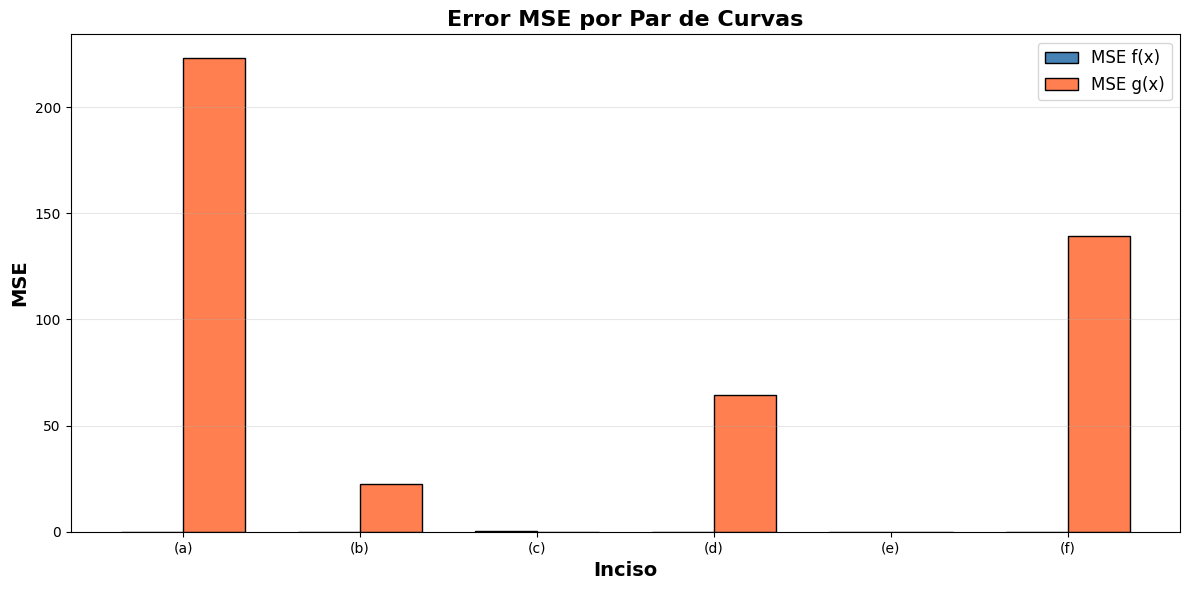

In [8]:
x_pos = np.arange(len(par_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x_pos - width/2, mse_f_list, width, label='MSE f(x)', color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, mse_g_list, width, label='MSE g(x)', color='coral', edgecolor='black')

ax.set_xlabel('Inciso', fontsize=14, fontweight='bold')
ax.set_ylabel('MSE', fontsize=14, fontweight='bold')
ax.set_title('Error MSE por Par de Curvas', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(par_labels)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('problema_2_errores.png', dpi=300, bbox_inches='tight')
plt.show()